In [1]:
import numpy as np
import cv2
import os
import random
import shutil
from pycocotools import mask as comosk

In [2]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core
# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

# Properly install detectron2. (Please do not install twice in both ways)
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 5.5 MB/s eta 0:00:00a 0:00:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 15943, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 15943 (delta 5), reused 4 (delta 4), pack-reused 15931 (from 3)
Receiving objects: 100% (15943/15943), 6.70 MiB | 21.56 MiB/s, done.
Resolving deltas: 100% (11337/11337), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match you

In [3]:
classes={
    "crust_edge":    (153, 217, 234),
    "charred_crust": (255, 58, 58),
    "sausage":       (211, 234, 211),
    "ham":           (255, 149, 0),
    "ground_beef":   (80, 172, 243),
    "tomato":        (255, 241, 204),
    "olives":        (255, 149, 210),
    "mushrooms":     (188, 255, 123),
}

In [4]:
cnames=list(classes.keys())
clrs={v:k for k,v in classes.items()}

In [5]:
random.seed(42)
imgd='/kaggle/input/food-segmentation/Food Segmentation/images'
mskd='/kaggle/input/food-segmentation/Food Segmentation/masks'
out='/kaggle/working/splitdataset'
os.makedirs(out,exist_ok=True)

In [6]:
sp={'train':0.7,'val':0.15,'test':0.15}

In [7]:
imgss=sorted(os.listdir(imgd))
assert len(imgss)==len(os.listdir(mskd))

In [8]:
random.shuffle(imgss)
n = len(imgss)
train_end = int(sp["train"] * n)
val_end = train_end + int(sp["val"] * n)
split_files = {
    "train": imgss[:train_end],
    "val": imgss[train_end:val_end],
    "test": imgss[val_end:]
}

for split, files in split_files.items():
    img_out = os.path.join(out, split, "images")
    mask_out = os.path.join(out, split, "masks")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(mask_out, exist_ok=True)

    for f in files:
        shutil.copy(
            os.path.join(imgd, f),
            os.path.join(img_out, f)
        )
        shutil.copy(
            os.path.join(mskd, f),
            os.path.join(mask_out, f)
        )

In [9]:
def bbbox(bmask):
    ys,xs=np.where(bmask)
    if len(xs)==0:
        return None
    xm,xma=xs.min(),xs.max()
    ym,yma=ys.min(),ys.max()
    return [int(xm),int(ym),int(xma),int(yma)]

In [10]:
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog,MetadataCatalog
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

In [16]:
def anno(img,msk):
    annotations=[]
    for clsid,(clsna,clr) in enumerate(classes.items()):
        cl=np.array(clr)
        cmask=np.all(msk==cl,axis=-1).astype(np.uint8)
        if cmask.sum()<50:
            continue
        numl,lbls=cv2.connectedComponents(cmask)
        for lbl in range(1,numl):
            imsk=(lbls==lbl).astype(np.uint8)
            if imsk.sum()<30:
                continue
            imsk=np.asfortranarray(imsk)
            rle=comosk.encode(imsk)
            rle['counts']=rle['counts'].decode('ascii')
            bbox=bbbox(imsk)
            annotations.append({
                "bbox": bbox,
                "bbox_mode": BoxMode.XYXY_ABS,
                "segmentation": rle,
                "category_id": clsid,
            })
    return annotations

In [12]:
def regi(imgdir,mskdir):
    dataset_dicts=[]
    for idx,file in enumerate(sorted(os.listdir(imgdir))):
        imgpth=os.path.join(imgdir,file)
        mskpth=os.path.join(mskdir,file)
        img=cv2.imread(imgpth)
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        msk=cv2.imread(mskpth)
        msk=cv2.cvtColor(msk,cv2.COLOR_BGR2RGB)
        record = {
                "file_name": imgpth,
                "image_id": idx,
                "height": img.shape[0],
                "width": img.shape[1],
                "annotations": anno(img, msk)
            }
        dataset_dicts.append(record)
    return dataset_dicts

In [13]:
DatasetCatalog.register('train',lambda:regi('/kaggle/working/splitdataset/train/images','/kaggle/working/splitdataset/train/masks'))
DatasetCatalog.register('val',lambda:regi('/kaggle/working/splitdataset/val/images','/kaggle/working/splitdataset/val/masks'))
DatasetCatalog.register('test',lambda:regi('/kaggle/working/splitdataset/test/images','/kaggle/working/splitdataset/test/masks'))


In [14]:
MetadataCatalog.get('train').set(thing_classes=cnames)
MetadataCatalog.get('test').set(thing_classes=cnames)
MetadataCatalog.get('val').set(thing_classes=cnames)

namespace(name='val',
          thing_classes=['crust_edge',
                         'charred_crust',
                         'sausage',
                         'ham',
                         'ground_beef',
                         'tomato',
                         'olives',
                         'mushrooms'])

findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', v

(np.float64(-0.5), np.float64(686.5), np.float64(1029.5), np.float64(-0.5))

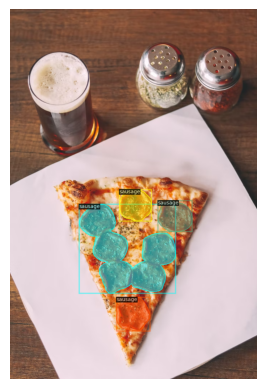

In [17]:
from detectron2.utils.visualizer import Visualizer
import matplotlib.pyplot as plt

dataset = DatasetCatalog.get("train")
metadata = MetadataCatalog.get("train")

sample = dataset[1]
img = cv2.imread(sample["file_name"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

vis = Visualizer(img, metadata=metadata, scale=1.0)
out = vis.draw_dataset_dict(sample)

plt.imshow(out.get_image())
plt.axis("off")


In [18]:
cfg=get_cfg()
cfg.merge_from_file(model_zoo.get_config_file('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml'))

In [19]:
cfg.DATASETS.TRAIN=('train',)
cfg.DATASETS.TEST=('val',)

In [20]:
cfg.MODEL.ROI_HEADS.NUM_CLASSES=len(cnames)

In [21]:
cfg.MODEL.WEIGHTS=model_zoo.get_checkpoint_url('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml')

In [22]:
cfg.SOLVER.IMS_PER_BATCH=2
cfg.SOLVER.BASE_LR=0.00025
cfg.SOLVER.MAX_ITER=3000
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE=128

In [23]:
cfg.OUTPUT_DIR='/kaggle/working/output'
os.makedirs(cfg.OUTPUT_DIR,exist_ok=True)

In [24]:
cfg.INPUT.MASK_FORMAT='bitmask'
cfg.TEST.EVAL_PERIOD=1000
cfg.MODEL.ROI_MASK_HEAD.CLS_AGNOSTIC_MASK=True
cfg.MODEL.ROI_MASK_HEAD.POOLER_RESOLUTION = 28

In [25]:
from detectron2.evaluation import COCOEvaluator
class CustomTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
            os.makedirs(output_folder, exist_ok=True)
        return COCOEvaluator(dataset_name, cfg, distributed=False, output_dir=output_folder)

In [26]:
traine=CustomTrainer(cfg)
traine.resume_or_load(resume=False)

Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2): Sequential(
        (0): Bottlene

SOLVER.STEPS contains values larger than SOLVER.MAX_ITER. These values will be ignored.


[DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


model_final_f10217.pkl: 178MB [00:00, 215MB/s]                               

Successfully downloaded /root/.torch/iopath_cache/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl. 177841981 bytes.
URL https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl cached in /root/.torch/iopath_cache/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl
[Checkpointer] Loading from /root/.torch/iopath_cache/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


Reading a file from 'Detectron2 Model Zoo'


Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (9, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (9,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (32, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (32,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) 

In [27]:
import PIL
PIL.ImageFile.LOAD_TRUNCATED_IMAGES = True
import logging
logging.getLogger("PIL").setLevel(logging.WARNING)

In [28]:
traine.train()

Starting training from iteration 0


/kaggle/working/detectron2/detectron2/data/detection_utils.py:449: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  torch.stack([torch.from_numpy(np.ascontiguousarray(x)) for x in masks])
/kaggle/working/detectron2/detectron2/data/detection_utils.py:449: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at

 eta: 0:27:45  iter: 19  total_loss: 5.891  loss_cls: 2.321  loss_box_reg: 0.6535  loss_mask: 0.6948  loss_rpn_cls: 1.936  loss_rpn_loc: 0.2229    time: 0.5432  last_time: 0.4654  data_time: 0.0628  last_data_time: 0.0078   lr: 4.9953e-06  max_mem: 2794M


2026-01-08 07:34:51.587549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767857691.771629      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767857691.826753      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767857692.267427      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767857692.267491      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767857692.267494      55 computation_placer.cc:177] computation placer alr

Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
Creating converter from 7 to 5
Creating converter from 5 to 7
Creating converter from 7 to 5
Creating converter from 5 to 7


...

Trying to convert 'val' to COCO format ...
Converting annotations of dataset 'val' to COCO format ...)
Converting dataset dicts into COCO format
Conversion finished, #images: 3, #annotations: 98
Caching COCO format annotations at '/kaggle/working/output/inference/val_coco_format.json' ...
Start inference on 3 batches
Total inference time: 0:00:00.282016 (0.282016 s / iter per device, on 1 devices)
Total inference pure compute time: 0:00:00 (0.161943 s / iter per device, on 1 devices)
Preparing results for COCO format ...
Saving results to /kaggle/working/output/inference/coco_instances_results.json
Evaluating predictions with official COCO API...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.057
 Average Precision  (AP) @[ IoU=0.50      | area=   a

COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.


Start inference on 3 batches
Total inference time: 0:00:00.250273 (0.250273 s / iter per device, on 1 devices)
Total inference pure compute time: 0:00:00 (0.148447 s / iter per device, on 1 devices)
Preparing results for COCO format ...
Saving results to /kaggle/working/output/inference/coco_instances_results.json
Evaluating predictions with official COCO API...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.067
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.096
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.083
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.073
 Average Precision  (AP

COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.


Start inference on 3 batches
Total inference time: 0:00:00.255723 (0.255723 s / iter per device, on 1 devices)
Total inference pure compute time: 0:00:00 (0.144015 s / iter per device, on 1 devices)
Preparing results for COCO format ...
Saving results to /kaggle/working/output/inference/coco_instances_results.json
Evaluating predictions with official COCO API...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.073
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.098
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.083
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.080
 Average Precision  (AP

In [29]:
!pip install tensorboard

In [31]:
%load_ext tensorboard
%tensorboard --logdir /kaggle/working/output

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 238), started 0:00:40 ago. (Use '!kill 238' to kill it.)

<IPython.core.display.Javascript object>